# Классификация Oxford Pets

Обучим сеть для классификации исходного датасета [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Загрузите датасет с Kaggle.

Загрузка, распаковка:

In [2]:
api_token = {"username":"kuznetsovmstislaw","key":"2ffd2ca21e04b381ac86046c8fe16010"}

import sys
import json

!{sys.executable} -m pip install kaggle

!mkdir ~/.kaggle
with open('kaggle.json', 'w') as file:
    json.dump(api_token, file)
!mv kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json


[notice] A new release of pip is available: 24.1 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ЋиЁЎЄ  ў бЁ­в ЄбЁбҐ Є®¬ ­¤л.


PermissionError: [Errno 13] Permission denied: 'kaggle.json'

In [ ]:
!kaggle datasets download -d tongpython/cat-and-dog
!unzip -q cat-and-dog.zip
!rm *.zip
#training and test

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 99% 215M/218M [00:14<00:00, 16.3MB/s]
100% 218M/218M [00:14<00:00, 15.8MB/s]


In [ ]:
!kaggle datasets download -d tanlikesmath/the-oxfordiiit-pet-dataset
!unzip -q the-oxfordiiit-pet-dataset.zip
!rm *.zip
# images

Dataset URL: https://www.kaggle.com/datasets/tanlikesmath/the-oxfordiiit-pet-dataset
License(s): CC-BY-SA-4.0
100% 1.47G/1.48G [01:23<00:00, 22.0MB/s]
100% 1.48G/1.48G [01:23<00:00, 18.9MB/s]


In [ ]:
%cd images/images
!rm *
%cd ..
!rmdir images
!rm *.mat
%cd ..

/content/images/images
/content/images
/content


In [ ]:
!find images -type f | wc -l

7390


In [ ]:
%cd images

/content/images


In [4]:
!dir

 ’®¬ ў гбва®©бвўҐ C Ё¬ҐҐв ¬ҐвЄг Acer
 ‘ҐаЁ©­л© ­®¬Ґа в®¬ : A0C2-45D1

 ‘®¤Ґа¦Ё¬®Ґ Ї ЇЄЁ C:\

21.09.2021  17:17    <DIR>          $WINDOWS.~BT
07.11.2007  08:00            17я734 eula.1028.txt
07.11.2007  08:00            17я734 eula.1031.txt
07.11.2007  08:00            10я134 eula.1033.txt
07.11.2007  08:00            17я734 eula.1036.txt
07.11.2007  08:00            17я734 eula.1040.txt
07.11.2007  08:00               118 eula.1041.txt
07.11.2007  08:00            17я734 eula.1042.txt
07.11.2007  08:00            17я734 eula.2052.txt
07.11.2007  08:00            17я734 eula.3082.txt
07.11.2007  08:00             1я110 globdata.ini
02.02.2024  02:38    <DIR>          GOG Games
07.11.2007  08:03           562я688 install.exe
07.11.2007  08:00               843 install.ini
07.11.2007  08:03            76я304 install.res.1028.dll
07.11.2007  08:03            96я272 install.res.1031.dll
07.11.2007  08:03            91я152 install.res.1033.dll
07.11.2007  08:03            97я296 install.re

Упорядочим изображения по папкам:

In [69]:
breeds = ['Abyssinian','Bengal','Bombay','Birman','British Shorthair','Maine Coon','Persian','Egyptian Mau','Ragdoll','Russian Blue',
          'Siamese','Sphynx',
          'Boxer','Keeshond','Havanese','Basset Hound','English Setter','Miniature Pinscher','Chihuahua',
          'Great Pyrenees','German Shorthaired','Beagle','Staffordshire Bull Terrier','English Cocker Spaniel',
          'newfoundland',
          'Pomeranian','Leonberger','American Pit Bull Terrier','Wheaten Terrier','Japanese Chin','samoyed','Scottish Terrier',
          'Shiba Inu','Pug','Saint Bernard','American Bulldog','Yorkshire Terrier']

for i in range(len(breeds)):
  if i > 11:
    breeds[i] = breeds[i].lower()
  breeds[i] = '_'.join(breeds[i].split(' '))
print(breeds)

['Abyssinian', 'Bengal', 'Bombay', 'Birman', 'British_Shorthair', 'Maine_Coon', 'Persian', 'Egyptian_Mau', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'boxer', 'keeshond', 'havanese', 'basset_hound', 'english_setter', 'miniature_pinscher', 'chihuahua', 'great_pyrenees', 'german_shorthaired', 'beagle', 'staffordshire_bull_terrier', 'english_cocker_spaniel', 'newfoundland', 'pomeranian', 'leonberger', 'american_pit_bull_terrier', 'wheaten_terrier', 'japanese_chin', 'samoyed', 'scottish_terrier', 'shiba_inu', 'pug', 'saint_bernard', 'american_bulldog', 'yorkshire_terrier']


In [ ]:
for breed in breeds:
  !mkdir {breed}
  !mv {breed}_* {breed}

%cd ..

['Abyssinian', 'Bengal', 'Bombay', 'Birman', 'British_Shorthair', 'Maine_Coon', 'Persian', 'Egyptian_Mau', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'boxer', 'keeshond', 'havanese', 'basset_hound', 'english_setter', 'miniature_pinscher', 'chihuahua', 'great_pyrenees', 'german_shorthaired', 'beagle', 'staffordshire_bull_terrier', 'english_cocker_spaniel', 'newfoundland', 'pomeranian', 'leonberger', 'american_pit_bull_terrier', 'wheaten_terrier', 'japanese_chin', 'samoyed', 'scottish_terrier', 'shiba_inu', 'pug', 'saint_bernard', 'american_bulldog', 'yorkshire_terrier']
/content


Используем следующие библиотеки:

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sn
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.utils import *

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Softmax
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import SparseTopKCategoricalAccuracy

from pathlib import Path
set_random_seed(1337)

import os
from PIL import Image

In [ ]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [29]:
%cd ..

C:\Users\mk010\Pets_nb


C:\users\mk010\appdata\local\programs\python\python39\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
%cd Users/mk010/Pets_nb/

C:\Users\mk010\Pets_nb


C:\users\mk010\appdata\local\programs\python\python39\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [30]:
!dir

 ’®¬ ў гбва®©бвўҐ C Ё¬ҐҐв ¬ҐвЄг Acer
 ‘ҐаЁ©­л© ­®¬Ґа в®¬ : A0C2-45D1

 ‘®¤Ґа¦Ё¬®Ґ Ї ЇЄЁ C:\Users\mk010\Pets_nb

17.09.2024  00:01    <DIR>          .
17.09.2024  00:01    <DIR>          ..
10.09.2024  18:47    <DIR>          cat-and-dog
30.09.2019  01:43       228я487я605 cat-and-dog.zip
10.09.2024  19:18    <DIR>          images
17.09.2024  00:01    <DIR>          images_balanced
10.09.2024  18:30                76 kaggle.json
18.10.2019  06:21     1я585я267я331 the-oxfordiiit-pet-dataset.zip
               3 д ©«®ў  1я813я755я012 Ў ©в
               5 Ї Ї®Є  196я135я518я208 Ў ©в бў®Ў®¤­®


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
tf.config.set_logical_device_configuration(
    gpus[0],
    [tf.config.LogicalDeviceConfiguration(memory_limit=2048)])
logical_gpus = tf.config.list_logical_devices('GPU')
print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")

1 Physical GPUs, 1 Logical GPUs


datagen:

In [42]:
img_size = (256, 256)
batch_size = 16
seed = 1337

In [ ]:
datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255.)

train_flow = datagen.flow_from_directory('training_set/training_set', target_size=img_size, batch_size=batch_size, class_mode='binary')
test_flow = datagen.flow_from_directory('test_set/test_set', target_size=img_size, batch_size=batch_size, class_mode='binary')

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [53]:
train_breeds, valid_breeds = image_dataset_from_directory(
    'images_balanced',
    validation_split=0.2,
    subset="both",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
)

Found 4900 files belonging to 37 classes.
Using 3920 files for training.
Using 980 files for validation.


Загрузим предобученные сети:

In [54]:
vgg_16 = keras.applications.vgg16.VGG16(weights='imagenet', include_top=False)
for x in vgg_16.layers:
  x.trainable = False
# vgg16.summary()

vgg_19 = keras.applications.vgg19.VGG19(weights='imagenet', include_top=False)
for x in vgg_19.layers:
  x.trainable = False
# vgg19.summary()

resnet_50 = keras.applications.resnet50.ResNet50(weights='imagenet', include_top=False)
for x in resnet_50.layers:
  x.trainable = False
# resnet50.summary()

Строим модели на основе vgg16, vgg19 и resnet50:

In [88]:
top3_acc = SparseTopKCategoricalAccuracy(k=3, name='top3_acc')
top5_acc = SparseTopKCategoricalAccuracy(k=5, name='top5_acc')

model16 = Sequential(name='vgg16_based')
model19 = Sequential(name='vgg19_based')
model50 = Sequential(name='resnet50_based')

models = [model16, model19, model50]
for m in models:
  m.add(Input(shape=(img_size[0], img_size[1], 3)))
  m.add(RandomFlip('horizontal'))
  m.add(RandomRotation(0.1))
  m.add(Rescaling(1./255.))

model16.add(vgg_16)
model19.add(vgg_19)
model50.add(resnet_50)

D0 = 256
D1 = 4736
DO = 0.3
LR = 0.0001

for m in models:
  m.add(Flatten())
  # m.add(Dense(D0, activation='relu'))
  # m.add(Dropout(DO))
  # m.add(Dense(D1, activation='relu'))
  m.add(Dropout(DO))
  m.add(Dense(37, activation='softmax'))
  m.summary()
  m.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy', top3_acc, top5_acc])

Model: "vgg16_based"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip_33 (RandomFlip)  (None, 256, 256, 3)      0         
                                                                 
 random_rotation_33 (RandomR  (None, 256, 256, 3)      0         
 otation)                                                        
                                                                 
 rescaling_33 (Rescaling)    (None, 256, 256, 3)       0         
                                                                 
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 flatten_33 (Flatten)        (None, 32768)             0         
                                                                 
 dropout_33 (Dropout)        (None, 32768)             0         
                                                       

Обучение модели на основе VGG16:

In [89]:
hist16 = model16.fit(train_breeds, validation_data=valid_breeds, epochs=15)

Epoch 1/15
245/245 [==============================] - 42s 161ms/step - loss: 3.1687 - accuracy: 0.1518 - top3_acc: 0.3250 - top5_acc: 0.4281 - val_loss: 2.4813 - val_accuracy: 0.2816 - val_top3_acc: 0.5551 - val_top5_acc: 0.7000
Epoch 2/15
245/245 [==============================] - 40s 163ms/step - loss: 2.1956 - accuracy: 0.3788 - top3_acc: 0.6505 - top5_acc: 0.7569 - val_loss: 2.0411 - val_accuracy: 0.4143 - val_top3_acc: 0.6837 - val_top5_acc: 0.7980
Epoch 3/15
245/245 [==============================] - 40s 164ms/step - loss: 1.7428 - accuracy: 0.5265 - top3_acc: 0.7681 - top5_acc: 0.8541 - val_loss: 1.8684 - val_accuracy: 0.4469 - val_top3_acc: 0.7122 - val_top5_acc: 0.8204
Epoch 4/15
245/245 [==============================] - 41s 167ms/step - loss: 1.4264 - accuracy: 0.6207 - top3_acc: 0.8337 - top5_acc: 0.9028 - val_loss: 1.6812 - val_accuracy: 0.4990 - val_top3_acc: 0.7551 - val_top5_acc: 0.8582
Epoch 5/15
245/245 [==============================] - 41s 166ms/step - loss: 1.2167 

Обучение модели на основе VGG19:

In [59]:
hist19 = model19.fit(train_breeds, validation_data=valid_breeds, epochs=15)

Epoch 1/15
245/245 [==============================] - 49s 193ms/step - loss: 3.3032 - accuracy: 0.1296 - top3_acc: 0.3904 - top5_acc: 0.4894 - val_loss: 2.6448 - val_accuracy: 0.2449 - val_top3_acc: 0.4990 - val_top5_acc: 0.6265
Epoch 2/15
245/245 [==============================] - 46s 187ms/step - loss: 2.4319 - accuracy: 0.3133 - top3_acc: 0.5551 - top5_acc: 0.6806 - val_loss: 2.2324 - val_accuracy: 0.3561 - val_top3_acc: 0.6153 - val_top5_acc: 0.7327
Epoch 3/15
245/245 [==============================] - 46s 189ms/step - loss: 1.9858 - accuracy: 0.4441 - top3_acc: 0.6980 - top5_acc: 0.8033 - val_loss: 2.0478 - val_accuracy: 0.3827 - val_top3_acc: 0.6694 - val_top5_acc: 0.8061
Epoch 4/15
245/245 [==============================] - 47s 191ms/step - loss: 1.7089 - accuracy: 0.5268 - top3_acc: 0.7620 - top5_acc: 0.8513 - val_loss: 1.8318 - val_accuracy: 0.4622 - val_top3_acc: 0.7276 - val_top5_acc: 0.8378
Epoch 5/15
245/245 [==============================] - 46s 188ms/step - loss: 1.4658 

Обучение модели на основе ResNet50:

In [60]:
hist50 = model50.fit(train_breeds, validation_data=valid_breeds, epochs=15)

Epoch 1/15
245/245 [==============================] - 40s 139ms/step - loss: 4.5241 - accuracy: 0.0446 - top3_acc: 0.2512 - top5_acc: 0.3273 - val_loss: 3.9625 - val_accuracy: 0.0592 - val_top3_acc: 0.1418 - val_top5_acc: 0.2051
Epoch 2/15
245/245 [==============================] - 32s 130ms/step - loss: 4.2417 - accuracy: 0.0531 - top3_acc: 0.1564 - top5_acc: 0.2426 - val_loss: 3.7730 - val_accuracy: 0.0602 - val_top3_acc: 0.2041 - val_top5_acc: 0.2867
Epoch 3/15
245/245 [==============================] - 32s 128ms/step - loss: 4.0386 - accuracy: 0.0717 - top3_acc: 0.1857 - top5_acc: 0.2829 - val_loss: 3.7747 - val_accuracy: 0.0735 - val_top3_acc: 0.2153 - val_top5_acc: 0.3051
Epoch 4/15
245/245 [==============================] - 30s 124ms/step - loss: 4.0558 - accuracy: 0.0844 - top3_acc: 0.1929 - top5_acc: 0.2883 - val_loss: 3.8496 - val_accuracy: 0.1041 - val_top3_acc: 0.2143 - val_top5_acc: 0.3092
Epoch 5/15
245/245 [==============================] - 30s 124ms/step - loss: 3.8903 

Сравним accuracy и loss для всех трех моделей:

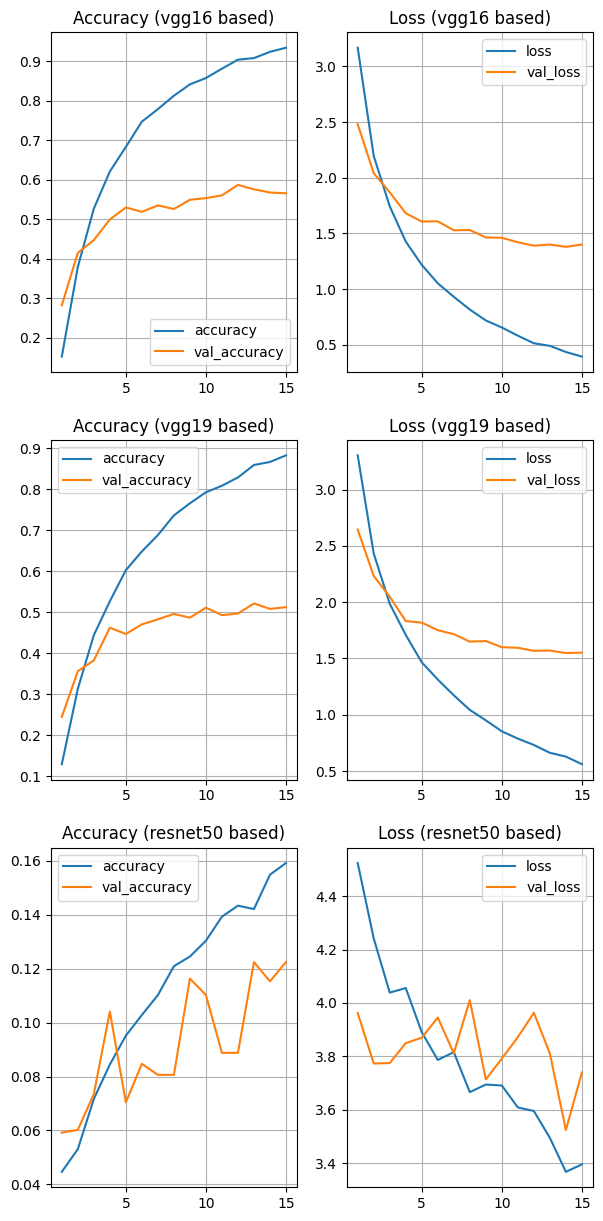

In [90]:
histories = [hist16, hist19, hist50]
names = [' (vgg16 based)', ' (vgg19 based)', ' (resnet50 based)']
ep=15
plt.figure(figsize=(7, 15))

for i in range(len(histories)):
  acc = histories[i].history['accuracy']
  val_acc = histories[i].history['val_accuracy']

  plt.subplot(3, 2, 2*(i+1)-1)
  plt.plot(range(1, ep + 1), acc, label='accuracy')
  plt.plot(range(1, ep + 1), val_acc, label='val_accuracy')
  plt.legend()
  plt.grid()
  plt.title('Accuracy' + names[i])

  loss = histories[i].history['loss']
  val_loss = histories[i].history['val_loss']

  plt.subplot(3, 2, 2*(i+1))
  plt.plot(range(1, ep + 1), loss, label='loss')
  plt.plot(range(1, ep + 1), val_loss, label='val_loss')
  plt.legend()
  plt.grid()
  plt.title('Loss' + names[i])

  # plt.subplot(3, 3, 2*(i+1)+1)
  # # plottext = 'D0 = ' + str(D0) + '\nD1 = ' + str(D1) + '\nDO = ' + str(DO) + '\nLR = ' + str(LR)
  # plottext = 'DO = ' + str(DO) + '\nLR = ' + str(LR)
  # plt.text(0.2, 0.4, plottext, size='xx-large')

plt.show()

Победила модель на основе vgg16, кошки против собак binary accuracy:

In [91]:
correct, total = 0, 0

cat_breeds = sorted(breeds[:12])
dog_breeds = sorted(breeds[12:])

cats = []
dogs = []

class_names = valid_breeds.class_names

# for i in range(len(class_names)):
#   print((cat_breeds + dog_breeds)[i], class_names[i])

for i in range(len(class_names)):
    if class_names[i] in cat_breeds:
        cats.append(i)
    if class_names[i] in dog_breeds:
        dogs.append(i)

for x, y in valid_breeds:
    y_pred = np.argmax(model16.predict(x), axis=1)
    # print(y_pred[0])
    # print(y[0])
    correct_cats = sum([y_pred[i] in cats and y[i] in cats for i in range(len(y))])
    correct_dogs = sum([y_pred[i] in dogs and y[i] in dogs for i in range(len(y))])
    correct += correct_cats + correct_dogs
    total += len(y)

print('\nBinary classification accuracy: ', correct / total)

1/1 [==============================] - 0s 30ms/step

Binary classification accuracy:  0.9306122448979591


Кошки против собак confusion matrix:

1/1 [==============================] - 0s 24ms/step


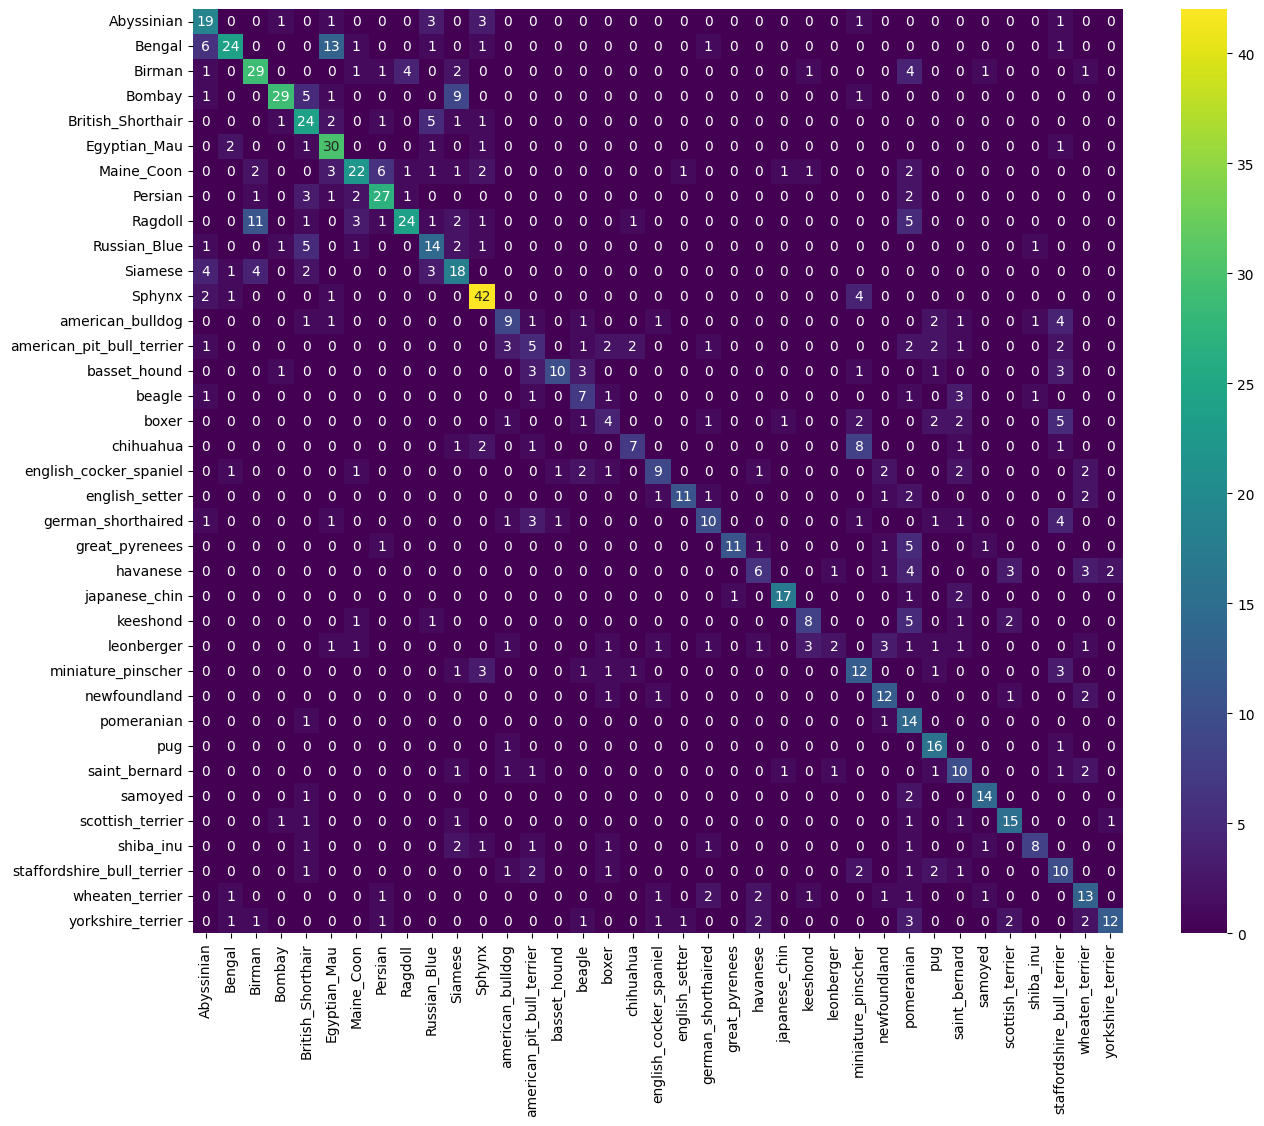

In [92]:
cn = valid_breeds.class_names
y_real = np.array([])
y_pred = np.array([])

for x, y in valid_breeds:
    y_real = np.concatenate((y_real, y), axis=None)
    y_pred = np.concatenate((y_pred, np.argmax(model16.predict(x), axis=1)), axis=None)

confusion_matrix = tf.math.confusion_matrix(y_real, y_pred, num_classes=37)

df_cm = pd.DataFrame(confusion_matrix, index = [i for i in cn], columns = [i for i in cn])

plt.figure(figsize = (15, 12))
sn.heatmap(df_cm, annot=True, cmap='viridis')
plt.show()

top-3, top-5 accuracy:

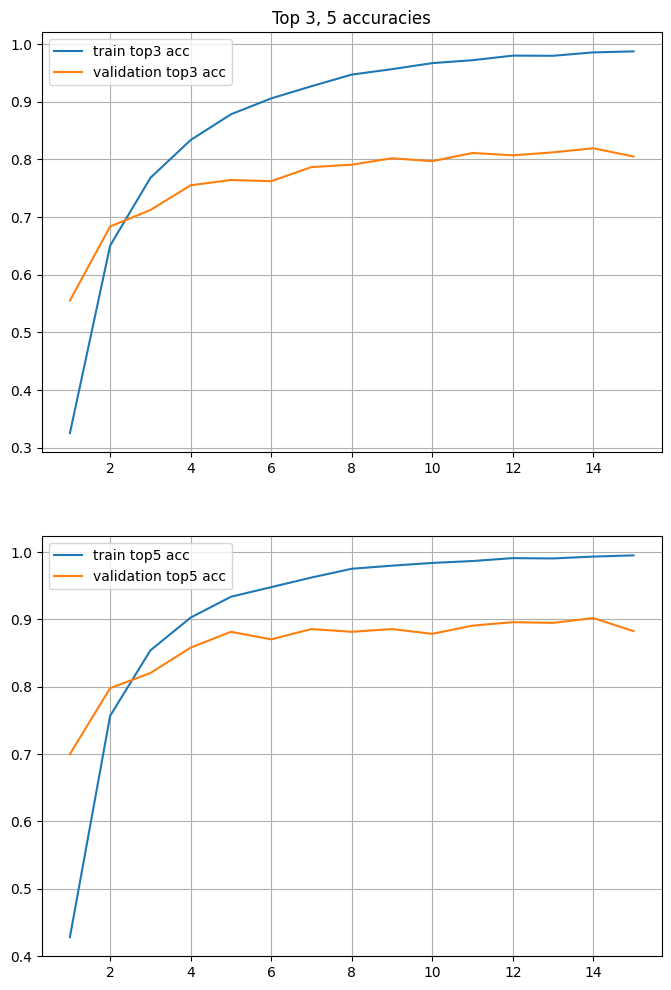

In [98]:
top3_accu = hist16.history['top3_acc']
val_top3_accu = hist16.history['val_top3_acc']

top5_accu = hist16.history['top5_acc']
val_top5_accu = hist16.history['val_top5_acc']

epochess = 15

plt.figure(figsize=(8, 12))
plt.subplot(2, 1, 1)
plt.title('Top 3, 5 accuracies')
plt.plot(range(1, epochess + 1), top3_accu, label='train top3 acc')
plt.plot(range(1, epochess + 1), val_top3_accu, label='validation top3 acc')
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(range(1, epochess + 1), top5_accu, label='train top5 acc')
plt.plot(range(1, epochess + 1), val_top5_accu, label='validation top5 acc')
plt.legend()
plt.grid()

plt.show()